In [1]:
import numpy as np
from scipy.stats import ks_2samp
from scipy import stats
from scipy import stats
import matplotlib.pyplot as plt
import h5py
import illustris_python as il
import sys
sys.path.append('../../py_files/')
#import weights
import control_sample as control
import BRAHMA_python as il_brahma
from tqdm import tqdm

import host_galaxy_enhancement_plots as hostplot
import host_utils as utils 
from astropy.cosmology import Planck15
from astropy import units as u

In [2]:
import os
tex_path = '/apps/texlive/2023/bin/x86_64-linux/'
os.environ['PATH'] += os.pathsep + tex_path
import scienceplots
plt.style.use('science')

In [3]:

pop_file_path = '/home/pranavsatheesh/host_galaxies/data/population_files/' 
tng_pop_file_path = '/home/pranavsatheesh/host_galaxies/data/population_files/'

print("For TNG50:")
TNG_basepath = '/orange/lblecha/IllustrisTNG/Runs/TNG50-1/output'
TNG_50_pop = control.load_pop_file(TNG_basepath,tng_pop_file_path,[0,0,1000,1])
TNG_50_control = control.control_samples_TNG(TNG_50_pop,max_Mstar_tolerance=0.15,max_z_tolerance=0.1)
TNG_color = '#d95f02'


brahma_basepath="/orange/lblecha/aklantbhowmick/GAS_BASED_SEED_MODEL_UNIFORM_RUNS/L12p5n512/AREPO/"
brahma_simName_array = ['SM5_TNG','SM5_LW10_TNG','SM5_DFD_3_TNG','SM5_LW10_DFD_3_TNG','SM5_LW10_LOWSPIN_TNG','SM5_LW10_LOWSPIN_RICH_TNG']
brahma_sim_colors = {
    brahma_simName_array[0]: '#bdc9e1', 
    brahma_simName_array[1]: '#67a9cf', 
    brahma_simName_array[2]: '#1c9099', 
    brahma_simName_array[3]: '#016c59',
    brahma_simName_array[4]: '#3690c0', 
    brahma_simName_array[5]: '#014636'  
}
brahma_sim_obj = {}
brahma_sim_zbins = {}
#brahma_sim_zbin_width = {}
for i,sim in enumerate(brahma_simName_array):
    print(sim)
    simPath = brahma_basepath + sim + '/'
    brahma_pop_Nstar10 = control.load_pop_file(simPath,pop_file_path,[10,10,10,1])
    if brahma_simName_array[i] == 'SM5_LW10_LOWSPIN_RICH_TNG':
        brahma_control = control.control_sample_brahma(brahma_pop_Nstar10,max_Mstar_tolerance=0.6,max_z_tolerance=0.2)
    else:
        brahma_control = control.control_sample_brahma(brahma_pop_Nstar10,max_Mstar_tolerance=0.15,max_z_tolerance=0.2)
    brahma_sim_obj[sim] = brahma_control
    #brahma_sim_zbin_width,brahma_sim_zbins[sim] =hostplot.find_best_z_width(brahma_control.z_merging_pop,z_min=0,z_max=10,z_width_initial=0.2)
    brahma_sim_zbins[sim] = hostplot.find_adaptive_z_bins(brahma_control.z_merging_pop,z_min=0,z_max=12,zbin_width=0.3,min_N_values=10)


TNG_50_zbins = hostplot.find_adaptive_z_bins(TNG_50_control.z_merging_pop,z_min=0,z_max=10,zbin_width=0.3,min_N_values=50)
print('TNG50',TNG_50_zbins )
brahma_zbins = hostplot.find_brahma_adaptive_z_bins(brahma_sim_obj,brahma_simName_array,z_lower=0,z_max=10,zbin_width=0.1,min_N_values=10)
print('Brahma common zbins:',brahma_zbins)


sim_names = brahma_simName_array + ['TNG50']
sim_colors = {sim: brahma_sim_colors[sim] for sim in brahma_simName_array}
sim_colors['TNG50'] = TNG_color
sim_objs = brahma_sim_obj
sim_objs['TNG50'] = TNG_50_control
sim_zbins_list = brahma_sim_zbins
#sim_zbins_list = {sim: brahma_zbins for sim in brahma_simName_array}
sim_zbins_list['TNG50'] = TNG_50_zbins

For TNG50:


finding controls: 100%|██████████| 504/504 [00:13<00:00, 38.31it/s] 
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:399: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop


Number of available mergers in this population is 504
Number of cases where a close enough match is not found within the acceptable tolerance: 16
SM5_TNG


finding controls: 100%|██████████| 773/773 [00:00<00:00, 26505.64it/s]
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:693: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:697: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_massive_pop = self.Mdot_massive_control_pop/self.MBH_massive_control_pop
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:700: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_luminous_pop = self.Mdot_luminous_control_pop/self.MBH_luminous_control_pop


Number of cases where a close enough match is not found within the acceptable tolerance: 172
number of processable mergers with valid controls:
581
[31, 40, 44, 65, 68, 83, 62, 39, 25, 13]
SM5_LW10_TNG


...

Number of cases where a close enough match is not found within the acceptable tolerance: 228
number of processable mergers with valid controls:
574
[40, 36, 51, 55, 62, 79, 78, 49, 18, 11]
SM5_LW10_LOWSPIN_TNG


finding controls: 100%|██████████| 488/488 [00:00<00:00, 27082.58it/s]


Number of cases where a close enough match is not found within the acceptable tolerance: 123
number of processable mergers with valid controls:
356
[27, 21, 21, 35, 28, 58, 45, 26, 24, 16, 10]
SM5_LW10_LOWSPIN_RICH_TNG


finding controls: 100%|██████████| 175/175 [00:00<00:00, 26033.10it/s]

Number of cases where a close enough match is not found within the acceptable tolerance: 25
number of processable mergers with valid controls:
149
[11, 12, 25, 20, 11, 11, 12, 10]
[55, 56, 54, 63, 65, 55, 68, 51]
TNG50 [0.  0.3 0.6 0.9 1.3 1.7 2.1 2.6 4.5]
Brahma common zbins: [0.  0.2 0.8 1.5 2.2 3.1 4.1 5.1 7.1]


In [4]:
t_delays = utils.find_merger_time_delays(sim_objs,sim_names)

In [43]:

def merger_enhancement_calc_for_mu(sim_obj,sim_name,quantity,merger_time_delay,td_threshold=0.5,Nmin=10,Nmajor=3,Nmini=3,Nminor=3,log=True):


    merger_time_delay_array = np.array(merger_time_delay[sim_name]['td'])
    small_td_mask = merger_time_delay_array < td_threshold
    z_with_small_td = sim_objs[sim_name].z_merging_pop[small_td_mask]
    unique_zs, counts_per_z = np.unique(z_with_small_td,return_counts=True)
    filtered_unique_zs = unique_zs[counts_per_z>=Nmin]
    unique_zs = filtered_unique_zs

    print(f"For sim {sim_name}")
    print("Unique zs with small td:",unique_zs)
    z_bins_major = []
    avg_quantity_enhancement_major = []
    std_quantity_enhancement_major = []

    z_bins_minor = []
    avg_quantity_enhancement_minor = []
    std_quantity_enhancement_minor = []

    z_bins_mini = []
    avg_quantity_enhancement_mini = []
    std_quantity_enhancement_mini = []

    for z in unique_zs:
        merger_z_mask = sim_obj.z_merging_pop== z
        major_merger_z_mask = sim_obj.major_merger_mask & merger_z_mask
        minor_merger_z_mask = sim_obj.minor_merger_mask & merger_z_mask
        mini_merger_z_mask  = sim_obj.mini_merger_mask & merger_z_mask
        
        print(f"z={z:.2f}: major mergers={np.sum(major_merger_z_mask)}, minor mergers={np.sum(minor_merger_z_mask)}, mini mergers={np.sum(mini_merger_z_mask)}")
        if log == True:
            quantity_log_enhancement_major = []
            quantity_log_enhancement_minor = []
            quantity_log_enhancement_mini = []


            #check if there is enough major mergers (default 3)
            if np.sum(major_merger_z_mask) >= Nmajor:
                z_bins_major.append(z)
                merging_pop_quantity = getattr(sim_obj,quantity+"_merging_pop")[major_merger_z_mask]
                control_pop_quantity = getattr(sim_obj,quantity+"_control_pop")[major_merger_z_mask]
                valid_mask = (merging_pop_quantity > 0) & (control_pop_quantity > 0)
                quantity_log_enhancement_major = np.log10(merging_pop_quantity[valid_mask] / control_pop_quantity[valid_mask])
                if len(quantity_log_enhancement_major) > 0:
                    avg_quantity_enhancement_major.append(np.median(quantity_log_enhancement_major))
                    std_quantity_enhancement_major.append(stats.sem(quantity_log_enhancement_major))
                else:
                    avg_quantity_enhancement_major.append(np.nan)
                    std_quantity_enhancement_major.append(np.nan)
            

            if np.sum(minor_merger_z_mask) >= Nminor:
                z_bins_minor.append(z)
                merging_pop_quantity = getattr(sim_obj,quantity+"_merging_pop")[minor_merger_z_mask]
                control_pop_quantity = getattr(sim_obj,quantity+"_control_pop")[minor_merger_z_mask]
                valid_mask = (merging_pop_quantity > 0) & (control_pop_quantity > 0)
                quantity_log_enhancement_minor = np.log10(merging_pop_quantity[valid_mask] / control_pop_quantity[valid_mask])
                if len(quantity_log_enhancement_minor) > 0:
                    avg_quantity_enhancement_minor.append(np.median(quantity_log_enhancement_minor))
                    std_quantity_enhancement_minor.append(stats.sem(quantity_log_enhancement_minor))    
                else:
                    avg_quantity_enhancement_minor.append(np.nan)
                    std_quantity_enhancement_minor.append(np.nan)
            
            if np.sum(mini_merger_z_mask) >= Nmini:
                z_bins_mini.append(z)
                merging_pop_quantity = getattr(sim_obj,quantity+"_merging_pop")[mini_merger_z_mask]
                control_pop_quantity = getattr(sim_obj,quantity+"_control_pop")[mini_merger_z_mask]
                valid_mask = (merging_pop_quantity > 0) & (control_pop_quantity > 0)
                quantity_log_enhancement_mini = np.log10(merging_pop_quantity[valid_mask] / control_pop_quantity[valid_mask])
                if len(quantity_log_enhancement_mini) > 0:
                    avg_quantity_enhancement_mini.append(np.median(quantity_log_enhancement_mini))
                    std_quantity_enhancement_mini.append(stats.sem(quantity_log_enhancement_mini))    
                else:
                    avg_quantity_enhancement_mini.append(np.nan)
                    std_quantity_enhancement_mini.append(np.nan)
        else:
            print("only log one coded up!")

    return (z_bins_major, avg_quantity_enhancement_major, std_quantity_enhancement_major,
            z_bins_minor, avg_quantity_enhancement_minor, std_quantity_enhancement_minor,
            z_bins_mini, avg_quantity_enhancement_mini, std_quantity_enhancement_mini)

In [87]:
def merger_enhancement_calc_for_mu_zbins(sim_obj, sim_name, quantity, merger_time_delay, 
                                          td_threshold=0.5, z_start=0, z_end=4, dz=1.0, 
                                          Nmajor=3, Nminor=3, Nmini=3, log=True):
    """
    Bin data into redshift bins of width dz and compute enhancements
    """
    merger_time_delay_array = np.array(merger_time_delay[sim_name]['td'])
    small_td_mask = merger_time_delay_array < td_threshold
    
    # Create redshift bins
    z_bins = np.arange(z_start, z_end + dz, dz)
    z_bin_centers = z_bins[:-1] + dz/2
    
    z_bins_major = []
    avg_quantity_enhancement_major = []
    std_quantity_enhancement_major = []
    
    z_bins_minor = []
    avg_quantity_enhancement_minor = []
    std_quantity_enhancement_minor = []
    
    z_bins_mini = []
    avg_quantity_enhancement_mini = []
    std_quantity_enhancement_mini = []
    
    print(f"For sim {sim_name}, binning in dz={dz} bins from z={z_start} to z={z_end}")
    
    for i in range(len(z_bins) - 1):
        z_low = z_bins[i]
        z_high = z_bins[i + 1]
        
        # Select mergers in this z bin with small time delay
        z_bin_mask = (sim_obj.z_merging_pop >= z_low) & (sim_obj.z_merging_pop < z_high) & small_td_mask
        
        major_merger_z_mask = sim_obj.major_merger_mask & z_bin_mask
        minor_merger_z_mask = sim_obj.minor_merger_mask & z_bin_mask
        mini_merger_z_mask = sim_obj.mini_merger_mask & z_bin_mask
        
        print(f"z=[{z_low:.1f}, {z_high:.1f}): major={np.sum(major_merger_z_mask)}, minor={np.sum(minor_merger_z_mask)}, mini={np.sum(mini_merger_z_mask)}")
        
        if log == True:
            # MAJOR MERGERS
            if np.sum(major_merger_z_mask) >= Nmajor:
                z_bins_major.append(z_bin_centers[i])
                merging_pop_quantity = getattr(sim_obj, quantity + "_merging_pop")[major_merger_z_mask]
                control_pop_quantity = getattr(sim_obj, quantity + "_control_pop")[major_merger_z_mask]
                valid_mask = (merging_pop_quantity > 0) & (control_pop_quantity > 0)
                quantity_log_enhancement = np.log10(merging_pop_quantity[valid_mask] / control_pop_quantity[valid_mask])
                if len(quantity_log_enhancement) > 0:
                    avg_quantity_enhancement_major.append(np.median(quantity_log_enhancement))
                    std_quantity_enhancement_major.append(stats.sem(quantity_log_enhancement))
                else:
                    avg_quantity_enhancement_major.append(np.nan)
                    std_quantity_enhancement_major.append(np.nan)
            
            # MINOR MERGERS
            if np.sum(minor_merger_z_mask) >= Nminor:
                z_bins_minor.append(z_bin_centers[i])
                merging_pop_quantity = getattr(sim_obj, quantity + "_merging_pop")[minor_merger_z_mask]
                control_pop_quantity = getattr(sim_obj, quantity + "_control_pop")[minor_merger_z_mask]
                valid_mask = (merging_pop_quantity > 0) & (control_pop_quantity > 0)
                quantity_log_enhancement = np.log10(merging_pop_quantity[valid_mask] / control_pop_quantity[valid_mask])
                if len(quantity_log_enhancement) > 0:
                    avg_quantity_enhancement_minor.append(np.median(quantity_log_enhancement))
                    std_quantity_enhancement_minor.append(stats.sem(quantity_log_enhancement))
                else:
                    avg_quantity_enhancement_minor.append(np.nan)
                    std_quantity_enhancement_minor.append(np.nan)
            
            # MINI MERGERS
            if np.sum(mini_merger_z_mask) >= Nmini:
                z_bins_mini.append(z_bin_centers[i])
                merging_pop_quantity = getattr(sim_obj, quantity + "_merging_pop")[mini_merger_z_mask]
                control_pop_quantity = getattr(sim_obj, quantity + "_control_pop")[mini_merger_z_mask]
                valid_mask = (merging_pop_quantity > 0) & (control_pop_quantity > 0)
                quantity_log_enhancement = np.log10(merging_pop_quantity[valid_mask] / control_pop_quantity[valid_mask])
                if len(quantity_log_enhancement) > 0:
                    avg_quantity_enhancement_mini.append(np.median(quantity_log_enhancement))
                    std_quantity_enhancement_mini.append(stats.sem(quantity_log_enhancement))
                else:
                    avg_quantity_enhancement_mini.append(np.nan)
                    std_quantity_enhancement_mini.append(np.nan)
    
    return (z_bins_major, avg_quantity_enhancement_major, std_quantity_enhancement_major,
            z_bins_minor, avg_quantity_enhancement_minor, std_quantity_enhancement_minor,
            z_bins_mini, avg_quantity_enhancement_mini, std_quantity_enhancement_mini)

For sim TNG50, binning in dz=1.0 bins from z=0 to z=4
z=[0.0, 1.0): major=38, minor=98, mini=48
z=[1.0, 2.0): major=53, minor=67, mini=27
z=[2.0, 3.0): major=31, minor=35, mini=26
z=[3.0, 4.0): major=14, minor=13, mini=13
For sim SM5_DFD_3_TNG
Unique zs with small td: [4.00794511 4.99593347 6.0107574 ]
z=4.01: major mergers=17, minor mergers=14, mini mergers=10
z=5.00: major mergers=14, minor mergers=10, mini mergers=4
z=6.01: major mergers=7, minor mergers=3, mini mergers=1
For sim SM5_LW10_LOWSPIN_RICH_TNG
Unique zs with small td: [4.00794511 4.99593347]
z=4.01: major mergers=6, minor mergers=2, mini mergers=3
z=5.00: major mergers=6, minor mergers=3, mini mergers=3
For sim TNG50, binning in dz=1.0 bins from z=0 to z=4
z=[0.0, 1.0): major=38, minor=98, mini=48
z=[1.0, 2.0): major=53, minor=67, mini=27
z=[2.0, 3.0): major=31, minor=35, mini=26
z=[3.0, 4.0): major=14, minor=13, mini=13
For sim SM5_DFD_3_TNG
Unique zs with small td: [4.00794511 4.99593347 6.0107574 ]
z=4.01: major merge

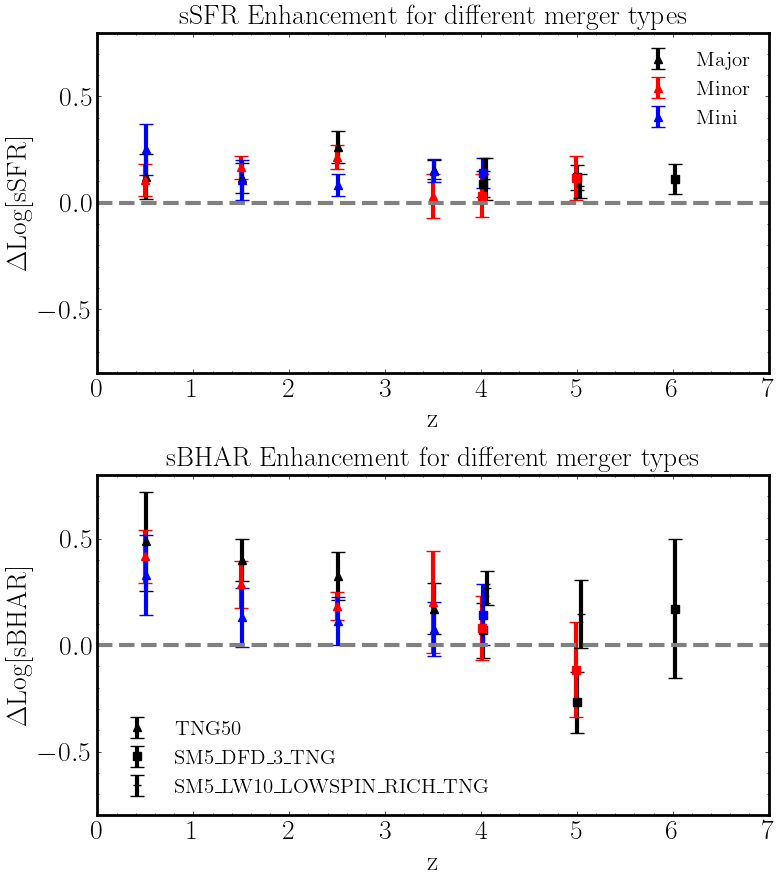

In [93]:
hostplot.set_plot_style(linewidth=3, titlesize=20,labelsize=20,xlabelsize=20,ylabelsize=20,legendsize=15)
fig,ax = plt.subplots(2,1,figsize=(8,9))
sim_markers = {'TNG50': '^','SM5_DFD_3_TNG': 's','SM5_LW10_LOWSPIN_RICH_TNG': '+'}
z_bins_TNG50_major,avg_sSFR_major_TNG50,std_sSFR_major_TNG50,z_bins_TNG50_minor,avg_sSFR_minor_TNG50,std_sSFR_minor_TNG50,z_bins_TNG50_mini,avg_sSFR_mini_TNG50,std_sSFR_mini_TNG50 = merger_enhancement_calc_for_mu_zbins(
        sim_objs['TNG50'], 'TNG50', 'sSFR', t_delays,
        td_threshold=0.5, z_start=0, z_end=4, dz=1.0,
        Nmajor=5, Nminor=5, Nmini=5, log=True
    )
z_offset = 0.01
ax[0].errorbar(np.array(z_bins_TNG50_major)+z_offset,avg_sSFR_major_TNG50,yerr=std_sSFR_major_TNG50,fmt=sim_markers['TNG50'],color='black',label='Major',capsize=5)
ax[0].errorbar(np.array(z_bins_TNG50_minor),avg_sSFR_minor_TNG50,yerr=std_sSFR_minor_TNG50,fmt=sim_markers['TNG50'],color='red',label='Minor',capsize=5)
ax[0].errorbar(np.array(z_bins_TNG50_mini)+z_offset,avg_sSFR_mini_TNG50,yerr=std_sSFR_mini_TNG50,fmt=sim_markers['TNG50'],color='blue',label='Mini',capsize=5)


z_bins_SM5_DFD_3_TNG_major,avg_sSFR_major_SM5_DFD_3_TNG,std_sSFR_major_SM5_DFD_3_TNG,z_bins_SM5_DFD_3_TNG_minor,avg_sSFR_minor_SM5_DFD_3_TNG,std_sSFR_minor_SM5_DFD_3_TNG,z_bins_SM5_DFD_3_TNG_mini,avg_sSFR_mini_SM5_DFD_3_TNG,std_sSFR_mini_SM5_DFD_3_TNG = merger_enhancement_calc_for_mu(sim_objs['SM5_DFD_3_TNG'],'SM5_DFD_3_TNG','sSFR',t_delays,td_threshold=0.5,Nmin=10,Nmajor=5,Nminor=5,Nmini=5,log=True)
z_offset = 0.01
ax[0].errorbar(np.array(z_bins_SM5_DFD_3_TNG_major)+z_offset,avg_sSFR_major_SM5_DFD_3_TNG,yerr=std_sSFR_major_SM5_DFD_3_TNG,fmt=sim_markers['SM5_DFD_3_TNG'],color='black',capsize=5)
ax[0].errorbar(np.array(z_bins_SM5_DFD_3_TNG_minor),avg_sSFR_minor_SM5_DFD_3_TNG,yerr=std_sSFR_minor_SM5_DFD_3_TNG,fmt=sim_markers['SM5_DFD_3_TNG'],color='red',capsize=5)
ax[0].errorbar(np.array(z_bins_SM5_DFD_3_TNG_mini)+z_offset,avg_sSFR_mini_SM5_DFD_3_TNG,yerr=std_sSFR_mini_SM5_DFD_3_TNG,fmt=sim_markers['SM5_DFD_3_TNG'],color='blue',capsize=5)


z_bins_SM5_LW10_LOWSPIN_RICH_TNG_major,avg_sSFR_major_SM5_LW10_LOWSPIN_RICH_TNG,std_sSFR_major_SM5_LW10_LOWSPIN_RICH_TNG,z_bins_SM5_LW10_LOWSPIN_RICH_TNG_minor,avg_sSFR_minor_SM5_LW10_LOWSPIN_RICH_TNG,std_sSFR_minor_SM5_LW10_LOWSPIN_RICH_TNG,z_bins_SM5_LW10_LOWSPIN_RICH_TNG_mini,avg_sSFR_mini_SM5_LW10_LOWSPIN_RICH_TNG,std_sSFR_mini_SM5_LW10_LOWSPIN_RICH_TNG = merger_enhancement_calc_for_mu(sim_objs['SM5_LW10_LOWSPIN_RICH_TNG'],'SM5_LW10_LOWSPIN_RICH_TNG','sSFR',t_delays,td_threshold=0.5,Nmin=10,Nmajor=5,Nminor=5,Nmini=5,log=True)
z_offset = 0.04
ax[0].errorbar(np.array(z_bins_SM5_LW10_LOWSPIN_RICH_TNG_major)+z_offset,avg_sSFR_major_SM5_LW10_LOWSPIN_RICH_TNG,yerr=std_sSFR_major_SM5_LW10_LOWSPIN_RICH_TNG,fmt=sim_markers['SM5_LW10_LOWSPIN_RICH_TNG'],color='black',capsize=5)
ax[0].errorbar(np.array(z_bins_SM5_LW10_LOWSPIN_RICH_TNG_minor),avg_sSFR_minor_SM5_LW10_LOWSPIN_RICH_TNG,yerr=std_sSFR_minor_SM5_LW10_LOWSPIN_RICH_TNG,fmt=sim_markers['SM5_LW10_LOWSPIN_RICH_TNG'],color='red',capsize=5)
ax[0].errorbar(np.array(z_bins_SM5_LW10_LOWSPIN_RICH_TNG_mini)+z_offset,avg_sSFR_mini_SM5_LW10_LOWSPIN_RICH_TNG,yerr=std_sSFR_mini_SM5_LW10_LOWSPIN_RICH_TNG,fmt=sim_markers['SM5_LW10_LOWSPIN_RICH_TNG'],color='blue',capsize=5)    

ax[0].set_xlabel('z')
ax[0].set_xlim(0,7)
ax[0].set_ylim(-0.8,0.8)
ax[0].axhline(0,ls='--',color='grey')
ax[0].set_ylabel(r'$\Delta \rm Log [sSFR]$')
ax[0].set_title('sSFR Enhancement for different merger types')
ax[0].legend()


z_bins_TNG50_major,avg_sBHAR_major_TNG50,std_sBHAR_major_TNG50,z_bins_TNG50_minor,avg_sBHAR_minor_TNG50,std_sBHAR_minor_TNG50,z_bins_TNG50_mini,avg_sBHAR_mini_TNG50,std_sBHAR_mini_TNG50 = \
    merger_enhancement_calc_for_mu_zbins(
        sim_objs['TNG50'], 'TNG50', 'sBHAR', t_delays,
        td_threshold=0.5, z_start=0, z_end=4, dz=1.0,
        Nmajor=5, Nminor=5, Nmini=5, log=True
    )
z_offset = 0.01
ax[1].errorbar(np.array(z_bins_TNG50_major)+z_offset,avg_sBHAR_major_TNG50,yerr=std_sBHAR_major_TNG50,fmt=sim_markers['TNG50'],color='black',label='TNG50',capsize=5)
ax[1].errorbar(np.array(z_bins_TNG50_minor),avg_sBHAR_minor_TNG50,yerr=std_sBHAR_minor_TNG50,fmt=sim_markers['TNG50'],color='red',capsize=5)
ax[1].errorbar(np.array(z_bins_TNG50_mini)+z_offset,avg_sBHAR_mini_TNG50,yerr=std_sBHAR_mini_TNG50,fmt=sim_markers['TNG50'],color='blue',capsize=5)      


z_bins_SM5_DFD_3_TNG_major,avg_sBHAR_major_SM5_DFD_3_TNG,std_sBHAR_major_SM5_DFD_3_TNG,z_bins_SM5_DFD_3_TNG_minor,avg_sBHAR_minor_SM5_DFD_3_TNG,std_sBHAR_minor_SM5_DFD_3_TNG,z_bins_SM5_DFD_3_TNG_mini,avg_sBHAR_mini_SM5_DFD_3_TNG,std_sBHAR_mini_SM5_DFD_3_TNG = merger_enhancement_calc_for_mu(sim_objs['SM5_DFD_3_TNG'],'SM5_DFD_3_TNG','sBHAR',t_delays,td_threshold=0.5,Nmin=10,Nmajor=5,Nminor=5,Nmini=5,log=True)
z_offset = 0.01
ax[1].errorbar(np.array(z_bins_SM5_DFD_3_TNG_major)+z_offset,avg_sBHAR_major_SM5_DFD_3_TNG,yerr=std_sBHAR_major_SM5_DFD_3_TNG,fmt=sim_markers['SM5_DFD_3_TNG'],color='black',label='SM5_DFD_3_TNG',capsize=5)
ax[1].errorbar(np.array(z_bins_SM5_DFD_3_TNG_minor),avg_sBHAR_minor_SM5_DFD_3_TNG,yerr=std_sBHAR_minor_SM5_DFD_3_TNG,fmt=sim_markers['SM5_DFD_3_TNG'],color='red',capsize=5)
ax[1].errorbar(np.array(z_bins_SM5_DFD_3_TNG_mini)+z_offset,avg_sBHAR_mini_SM5_DFD_3_TNG,yerr=std_sBHAR_mini_SM5_DFD_3_TNG,fmt=sim_markers['SM5_DFD_3_TNG'],color='blue',capsize=5)      


z_bins_SM5_LW10_LOWSPIN_RICH_TNG_major,avg_sBHAR_major_SM5_LW10_LOWSPIN_RICH_TNG,std_sBHAR_major_SM5_LW10_LOWSPIN_RICH_TNG,z_bins_SM5_LW10_LOWSPIN_RICH_TNG_minor,avg_sBHAR_minor_SM5_LW10_LOWSPIN_RICH_TNG,std_sBHAR_minor_SM5_LW10_LOWSPIN_RICH_TNG,z_bins_SM5_LW10_LOWSPIN_RICH_TNG_mini,avg_sBHAR_mini_SM5_LW10_LOWSPIN_RICH_TNG,std_sBHAR_mini_SM5_LW10_LOWSPIN_RICH_TNG = merger_enhancement_calc_for_mu(sim_objs['SM5_LW10_LOWSPIN_RICH_TNG'],'SM5_LW10_LOWSPIN_RICH_TNG','sBHAR',t_delays,td_threshold=0.5,Nmin=10,Nmajor=5,Nminor=5,Nmini=5,log=True)
z_offset = 0.05
ax[1].errorbar(np.array(z_bins_SM5_LW10_LOWSPIN_RICH_TNG_major)+z_offset,avg_sBHAR_major_SM5_LW10_LOWSPIN_RICH_TNG,yerr=std_sBHAR_major_SM5_LW10_LOWSPIN_RICH_TNG,fmt=sim_markers['SM5_LW10_LOWSPIN_RICH_TNG'],color='black',label='SM5_LW10_LOWSPIN_RICH_TNG',capsize=5)
ax[1].errorbar(np.array(z_bins_SM5_LW10_LOWSPIN_RICH_TNG_minor),avg_sBHAR_minor_SM5_LW10_LOWSPIN_RICH_TNG,yerr=std_sBHAR_minor_SM5_LW10_LOWSPIN_RICH_TNG,fmt=sim_markers['SM5_LW10_LOWSPIN_RICH_TNG'],color='red',capsize=5)
ax[1].errorbar(np.array(z_bins_SM5_LW10_LOWSPIN_RICH_TNG_mini)+z_offset,avg_sBHAR_mini_SM5_LW10_LOWSPIN_RICH_TNG,yerr=std_sBHAR_mini_SM5_LW10_LOWSPIN_RICH_TNG,fmt=sim_markers['SM5_LW10_LOWSPIN_RICH_TNG'],color='blue',capsize=5) 

ax[1].set_xlabel('z')
ax[1].axhline(0,ls='--',color='grey')
ax[1].set_xlim(0,7)
ax[1].set_ylim(-0.8,0.8)
ax[1].set_ylabel(r'$\Delta \rm Log[sBHAR] $')
ax[1].set_title('sBHAR Enhancement for different merger types')
ax[1].legend()
fig.tight_layout()
fig.savefig("../../figures/merger_enhancement_vs_redshift_for_different_merger_types_TNG50_BRAHMA.pdf")